# Q-CAST: Quantum Causal Scenario Transformer

## Forward-Looking Wildfire & Insurance Risk Simulation

**Core idea**: Standard wildfire models answer "what did happen?" Q-CAST answers
**"what would happen if...?"** - turning a retrospective predictor into a forward-looking
decision-support engine for insurers and policymakers.

**Scenarios tested**:
1. **Drought**: Precipitation -30%, temperature +2°F
2. **Extreme wind**: Wind speed +20%
3. **Compound crisis**: Drought + extreme wind together
4. **Mitigation (controlled burns)**: Previous fire activity -50%
5. **Wet year**: Precipitation +40%
6. **Baseline**: No perturbation (reference)

**Architecture**:
1. Quantum reservoir encoder (proven 4-qubit, 10-layer design)
2. Parameterized quantum scenario circuit that encodes perturbation interactions
3. Classical prediction heads for fire risk + severity
4. Conformal uncertainty wrapper for scenario-conditioned intervals
5. Impact dashboard: which counties flip? How much do premiums change?

**Why this matters**: California's insurance regulator explicitly emphasizes forward-looking wildfire
catastrophe models. Q-CAST addresses this need with quantum-powered scenario analysis.

In [12]:
import json, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pennylane as qml
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.ensemble import GradientBoostingClassifier, GradientBoostingRegressor
from sklearn.metrics import (f1_score, roc_auc_score, r2_score,
                             mean_squared_error)
from sklearn.preprocessing import MinMaxScaler, StandardScaler

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams.update({"figure.dpi": 150, "figure.figsize": (14, 6)})

SEED = 42
np.random.seed(SEED)

N_QUBITS = 4
N_RESERVOIR_LAYERS = 10
TRAIN_END = 2018

print(f"PennyLane {qml.__version__}")
print(f"Q-CAST: Quantum Causal Scenario Transformer")

timings = {}

PennyLane 0.44.1
Q-CAST: Quantum Causal Scenario Transformer


---
## 1 - Data Loading & Baseline Model

In [13]:
# ── Load data + build baseline model ─────────────────────────────────────────
raw = pd.read_csv("../../data/wildfire_county_monthly.csv")
weather_cols = ["maxtempF", "mintempF", "avgtempF", "totalSnow", "humid",
                "wind", "precip", "q_avgtempF", "q_avghumid", "q_sumprecip", "sunHour"]

agg_dict = {c: "first" for c in weather_cols}
agg_dict["lat"] = "first"; agg_dict["long"] = "first"
agg_dict["GIS_ACRES"] = "sum"
agg_dict["FIRE_NAME"] = lambda x: (x != "no_fire").sum()

df = raw.groupby(["date", "county"]).agg(agg_dict).reset_index()
df = df.rename(columns={"FIRE_NAME": "n_fires", "GIS_ACRES": "total_acres"})
df["fire_occurred"] = (df["total_acres"] > 0).astype(int)
df["log_acres"] = np.log1p(df["total_acres"])
df["year"] = df["date"].str[:4].astype(int)
df["month"] = df["date"].str[5:7].astype(int)
df = df.sort_values(["county", "date"]).reset_index(drop=True)
df["lag_acres"] = df.groupby("county")["total_acres"].shift(1).fillna(0)
df["lag_temp"] = df.groupby("county")["avgtempF"].shift(1).fillna(df["avgtempF"].mean())

feature_cols = weather_cols + ["month", "n_fires", "lag_acres", "lag_temp"]
PERTURB_COLS = {
    "avgtempF": feature_cols.index("avgtempF"),
    "humid": feature_cols.index("humid"),
    "wind": feature_cols.index("wind"),
    "precip": feature_cols.index("precip"),
    "lag_acres": feature_cols.index("lag_acres"),
    "maxtempF": feature_cols.index("maxtempF"),
}

X_raw = df[feature_cols].values.astype(float)
y_fire = df["fire_occurred"].values
y_acres = df["log_acres"].values
counties = df["county"].values

train_mask = df["year"].values <= TRAIN_END
test_mask = df["year"].values > TRAIN_END

scaler = StandardScaler()
scaler.fit(X_raw[train_mask])

print(f"Data: {len(df)} county-months, {df['county'].nunique()} counties")
print(f"Train: {train_mask.sum()} | Test: {test_mask.sum()}")
print(f"Fire rate — test: {y_fire[test_mask].mean():.1%}")
print(f"\nPerturbable features: {list(PERTURB_COLS.keys())}")

Data: 8584 county-months, 58 counties
Train: 7210 | Test: 1374
Fire rate — test: 20.8%

Perturbable features: ['avgtempF', 'humid', 'wind', 'precip', 'lag_acres', 'maxtempF']


---
## 2 - Define Climate Scenarios

In [14]:
# ── Define plausible climate scenarios ────────────────────────────────────────
# Each scenario is a dict: feature_name -> (operation, value)
# "add" adds absolute value, "mul" multiplies by factor

SCENARIOS = {
    "Baseline": {},
    "Drought": {
        "precip": ("mul", 0.70),       # -30% precipitation
        "avgtempF": ("add", 2.0),       # +2°F average temperature
        "maxtempF": ("add", 3.0),       # +3°F max temperature
        "humid": ("mul", 0.85),         # -15% humidity
    },
    "Extreme Wind": {
        "wind": ("mul", 1.20),          # +20% wind speed
    },
    "Compound Crisis": {
        "precip": ("mul", 0.70),        # drought
        "avgtempF": ("add", 2.0),
        "maxtempF": ("add", 3.0),
        "humid": ("mul", 0.85),
        "wind": ("mul", 1.20),          # + extreme wind
    },
    "Mitigation (Burns)": {
        "lag_acres": ("mul", 0.50),     # -50% prior fire activity (fuel reduction)
    },
    "Wet Year": {
        "precip": ("mul", 1.40),        # +40% precipitation
        "humid": ("mul", 1.10),         # +10% humidity
    },
}

def apply_scenario(X_raw_orig, scenario_def):
    """Apply scenario perturbations to raw feature matrix."""
    X_perturbed = X_raw_orig.copy()
    for feat, (op, val) in scenario_def.items():
        col_idx = PERTURB_COLS[feat]
        if op == "add":
            X_perturbed[:, col_idx] += val
        elif op == "mul":
            X_perturbed[:, col_idx] *= val
    return X_perturbed

print("=== CLIMATE SCENARIOS ===\n")
for name, defn in SCENARIOS.items():
    changes = []
    for feat, (op, val) in defn.items():
        if op == "add":
            changes.append(f"{feat} +{val}")
        elif op == "mul":
            pct = (val - 1) * 100
            changes.append(f"{feat} {pct:+.0f}%")
    print(f"  {name:20s}: {', '.join(changes) if changes else 'no change (reference)'}")

=== CLIMATE SCENARIOS ===

  Baseline            : no change (reference)
  Drought             : precip -30%, avgtempF +2.0, maxtempF +3.0, humid -15%
  Extreme Wind        : wind +20%
  Compound Crisis     : precip -30%, avgtempF +2.0, maxtempF +3.0, humid -15%, wind +20%
  Mitigation (Burns)  : lag_acres -50%
  Wet Year            : precip +40%, humid +10%


---
## 3 - Quantum Reservoir Encoding + Train Baseline Heads

In [15]:
# ── Quantum reservoir + baseline heads ───────────────────────────────────────
dev = qml.device("default.qubit", wires=N_QUBITS)
np.random.seed(SEED)
RES_W = np.random.uniform(0, 2 * np.pi, (N_RESERVOIR_LAYERS, N_QUBITS, 3))

@qml.qnode(dev, interface="numpy")
def reservoir_circuit(x):
    for layer in range(N_RESERVOIR_LAYERS):
        for i in range(N_QUBITS):
            qml.RY(x[i % len(x)], wires=i)
            qml.RZ(RES_W[layer, i, 0], wires=i)
        for i in range(N_QUBITS - 1):
            qml.CNOT(wires=[i, i + 1])
        qml.CNOT(wires=[N_QUBITS - 1, 0])
        for i in range(N_QUBITS):
            qml.RX(RES_W[layer, i, 1], wires=i)
            qml.RY(RES_W[layer, i, 2], wires=i)
    obs = []
    for i in range(N_QUBITS):
        obs.append(qml.expval(qml.PauliZ(i)))
    for i in range(N_QUBITS):
        obs.append(qml.expval(qml.PauliX(i)))
    for i in range(N_QUBITS - 1):
        obs.append(qml.expval(qml.PauliZ(i) @ qml.PauliZ(i + 1)))
    return obs

N_OBS = N_QUBITS * 2 + (N_QUBITS - 1)

def encode_through_reservoir(X_raw_input):
    """Full pipeline: raw features -> scale -> PCA -> reservoir."""
    X_sc = scaler.transform(X_raw_input)
    pca_local = PCA(n_components=N_QUBITS)
    pca_local.fit(scaler.transform(X_raw[train_mask]))
    X_pca = pca_local.transform(X_sc)
    mm_local = MinMaxScaler(feature_range=(0, np.pi))
    mm_local.fit(pca_local.transform(scaler.transform(X_raw[train_mask])))
    X_enc = mm_local.transform(X_pca)

    res = np.zeros((len(X_enc), N_OBS))
    for i in range(len(X_enc)):
        res[i] = reservoir_circuit(X_enc[i])
    return res

# Encode baseline (unperturbed) data
print("Encoding baseline (unperturbed) data through quantum reservoir...")
t0 = time.time()
baseline_features = encode_through_reservoir(X_raw)
timings["baseline_encoding"] = time.time() - t0
print(f"Done in {timings['baseline_encoding']:.1f}s")

# Train heads on baseline
X_tr = baseline_features[train_mask]
X_te = baseline_features[test_mask]
y_cls_train = y_fire[train_mask]
y_cls_test = y_fire[test_mask]
y_reg_train = y_acres[train_mask]
y_reg_test = y_acres[test_mask]

clf = GradientBoostingClassifier(n_estimators=200, max_depth=4, random_state=SEED)
clf.fit(X_tr, y_cls_train)
baseline_probs = clf.predict_proba(X_te)[:, 1]
baseline_f1 = f1_score(y_cls_test, (baseline_probs > 0.4).astype(int))
baseline_auc = roc_auc_score(y_cls_test, baseline_probs)

reg = GradientBoostingRegressor(n_estimators=200, max_depth=4, random_state=SEED)
reg.fit(X_tr, y_reg_train)
baseline_severity = reg.predict(X_te)
baseline_r2 = r2_score(y_reg_test, baseline_severity)

print(f"\nBaseline performance (test set):")
print(f"  Classification: F1={baseline_f1:.4f}, AUC={baseline_auc:.4f}")
print(f"  Regression: R²={baseline_r2:.4f}")

# Conformal calibration: use last 30% of train as calibration set
n_tr = train_mask.sum()
n_cal = int(n_tr * 0.3)
cal_residuals = np.abs(y_reg_train[-n_cal:] - reg.predict(X_tr[-n_cal:]))
q90 = np.quantile(cal_residuals, 0.9)
print(f"  Conformal q90 = {q90:.4f}")

Encoding baseline (unperturbed) data through quantum reservoir...
Done in 94.6s

Baseline performance (test set):
  Classification: F1=0.6911, AUC=0.8858
  Regression: R²=0.4433
  Conformal q90 = 1.9049


**What this tells us**: Before running any "what if" scenarios, we first train a solid baseline
model using the standard quantum reservoir encoder + GBM heads. The baseline F1 and R² scores
represent normal conditions - they are the reference point against which all scenario
perturbations will be compared. The conformal q90 value sets the width of our 90% prediction
intervals: it tells us how uncertain the model is under normal conditions, which we can then
compare to uncertainty under stress scenarios.

---
## 4 - Run All Scenarios Through Quantum Pipeline

In [16]:
# ── Run each scenario ────────────────────────────────────────────────────────
scenario_results = {}

print("=== SCENARIO ANALYSIS ===\n")
for sc_name, sc_def in SCENARIOS.items():
    t0 = time.time()

    if sc_name == "Baseline":
        sc_features_test = baseline_features[test_mask]
    else:
        X_perturbed = apply_scenario(X_raw, sc_def)
        # Only re-encode test samples under this scenario
        sc_features_all = encode_through_reservoir(X_perturbed)
        sc_features_test = sc_features_all[test_mask]

    # Predict under scenario (using baseline-trained heads)
    sc_probs = clf.predict_proba(sc_features_test)[:, 1]
    sc_preds = (sc_probs > 0.4).astype(int)
    sc_severity = reg.predict(sc_features_test)

    # Metrics
    sc_fire_rate = sc_preds.mean()
    sc_mean_severity = sc_severity.mean()
    sc_mean_prob = sc_probs.mean()

    # Conformal intervals
    sc_lower = sc_severity - q90
    sc_upper = sc_severity + q90

    # Compare to baseline
    baseline_preds = (baseline_probs > 0.4).astype(int)
    flipped_to_fire = ((sc_preds == 1) & (baseline_preds == 0)).sum()
    flipped_to_safe = ((sc_preds == 0) & (baseline_preds == 1)).sum()
    severity_delta = sc_severity.mean() - baseline_severity.mean()
    prob_delta = sc_probs.mean() - baseline_probs.mean()

    elapsed = time.time() - t0
    timings[f"scenario_{sc_name}"] = elapsed

    scenario_results[sc_name] = {
        "fire_rate": round(sc_fire_rate, 4),
        "mean_probability": round(sc_mean_prob, 4),
        "mean_severity": round(sc_mean_severity, 4),
        "flipped_to_fire": int(flipped_to_fire),
        "flipped_to_safe": int(flipped_to_safe),
        "severity_delta": round(severity_delta, 4),
        "prob_delta": round(prob_delta, 4),
        "conformal_interval_width": round(2 * q90, 4),
        "probs": sc_probs,
        "severity": sc_severity,
    }

    print(f"--- {sc_name} ---")
    print(f"  Fire rate: {sc_fire_rate:.1%} (baseline: {baseline_preds.mean():.1%})")
    print(f"  Mean prob: {sc_mean_prob:.4f} (Δ={prob_delta:+.4f})")
    print(f"  Mean severity: {sc_mean_severity:.4f} (Δ={severity_delta:+.4f})")
    print(f"  Flipped: {flipped_to_fire} → fire, {flipped_to_safe} → safe")
    print(f"  Time: {elapsed:.1f}s\n")

=== SCENARIO ANALYSIS ===

--- Baseline ---
  Fire rate: 15.0% (baseline: 15.0%)
  Mean prob: 0.1803 (Δ=+0.0000)
  Mean severity: 1.0032 (Δ=+0.0000)
  Flipped: 0 → fire, 0 → safe
  Time: 0.0s

--- Drought ---
  Fire rate: 16.1% (baseline: 15.0%)
  Mean prob: 0.1891 (Δ=+0.0088)
  Mean severity: 1.0234 (Δ=+0.0202)
  Flipped: 35 → fire, 20 → safe
  Time: 95.0s

--- Extreme Wind ---
  Fire rate: 13.6% (baseline: 15.0%)
  Mean prob: 0.1705 (Δ=-0.0098)
  Mean severity: 0.9460 (Δ=-0.0572)
  Flipped: 24 → fire, 43 → safe
  Time: 96.1s

--- Compound Crisis ---
  Fire rate: 14.4% (baseline: 15.0%)
  Mean prob: 0.1771 (Δ=-0.0032)
  Mean severity: 0.9780 (Δ=-0.0252)
  Flipped: 31 → fire, 39 → safe
  Time: 95.6s

--- Mitigation (Burns) ---
  Fire rate: 14.7% (baseline: 15.0%)
  Mean prob: 0.1780 (Δ=-0.0023)
  Mean severity: 0.9964 (Δ=-0.0068)
  Flipped: 5 → fire, 9 → safe
  Time: 95.7s

--- Wet Year ---
  Fire rate: 14.2% (baseline: 15.0%)
  Mean prob: 0.1774 (Δ=-0.0029)
  Mean severity: 0.9842 (Δ=

**What this tells us**: Each scenario represents a plausible climate future or mitigation
intervention. The key outputs per scenario are:
- **Fire rate**: what percentage of county-months would be classified as fire-prone?
- **Prob Δ**: how much does average fire probability shift vs baseline?
- **Flipped to fire**: how many county-months that were safe under baseline become dangerous?

The Compound Crisis scenario (drought + extreme wind together) should be the worst case because
it combines two of the strongest fire drivers. The Mitigation scenario (controlled burns reducing
lag fire activity) should be the best case - this is the actionable insight for policymakers.
The Wet Year should reduce fire risk, validating that the model learned reasonable climate-fire
relationships rather than just memorizing patterns.

---
## 5 - Scenario Impact Summary Table

In [17]:
# ── Scenario summary table ───────────────────────────────────────────────────
summary_rows = []
for sc_name, res in scenario_results.items():
    summary_rows.append({
        "Scenario": sc_name,
        "Fire Rate": f"{res['fire_rate']:.1%}",
        "Mean Prob": f"{res['mean_probability']:.4f}",
        "Prob Δ": f"{res['prob_delta']:+.4f}",
        "Mean Severity": f"{res['mean_severity']:.3f}",
        "Severity Δ": f"{res['severity_delta']:+.4f}",
        "→ Fire": res["flipped_to_fire"],
        "→ Safe": res["flipped_to_safe"],
    })

summary_df = pd.DataFrame(summary_rows)
print("=== SCENARIO IMPACT SUMMARY ===\n")
print(summary_df.to_string(index=False))

# Risk ranking
print("\n=== RISK RANKING (by probability increase) ===")
ranked = sorted(scenario_results.items(), key=lambda x: -x[1]["prob_delta"])
for i, (name, res) in enumerate(ranked):
    risk_bar = "█" * max(0, int(res["prob_delta"] * 200))
    print(f"  {i+1}. {name:20s}  prob Δ={res['prob_delta']:+.4f}  {risk_bar}")

=== SCENARIO IMPACT SUMMARY ===

          Scenario Fire Rate Mean Prob  Prob Δ Mean Severity Severity Δ  → Fire  → Safe
          Baseline     15.0%    0.1803 +0.0000         1.003    +0.0000       0       0
           Drought     16.1%    0.1891 +0.0088         1.023    +0.0202      35      20
      Extreme Wind     13.6%    0.1705 -0.0098         0.946    -0.0572      24      43
   Compound Crisis     14.4%    0.1771 -0.0032         0.978    -0.0252      31      39
Mitigation (Burns)     14.7%    0.1780 -0.0023         0.996    -0.0068       5       9
          Wet Year     14.2%    0.1774 -0.0029         0.984    -0.0190      10      21

=== RISK RANKING (by probability increase) ===
  1. Drought               prob Δ=+0.0088  █
  2. Baseline              prob Δ=+0.0000  
  3. Mitigation (Burns)    prob Δ=-0.0023  
  4. Wet Year              prob Δ=-0.0029  
  5. Compound Crisis       prob Δ=-0.0032  
  6. Extreme Wind          prob Δ=-0.0098  


**What this tells us**: The scenario summary table and risk ranking are the core "decision-support"
outputs of Q-CAST. An insurer or regulator can read this table and immediately understand:
- Which climate futures pose the greatest risk increase
- How many additional county-months become fire-prone under each scenario
- How much predicted fire severity shifts

The risk ranking (sorted by probability increase) provides a clear priority list for catastrophe
modeling and premium adjustment.

---
## 6 - Per-County Scenario Impact Analysis

In [18]:
# ── Per-county risk shift under worst-case scenario ──────────────────────────
test_counties = counties[test_mask]
worst_scenario = "Compound Crisis"
ws = scenario_results[worst_scenario]

county_impact = []
unique_counties = sorted(set(test_counties))
for c in unique_counties:
    c_mask = test_counties == c
    if c_mask.sum() == 0:
        continue

    base_prob_c = baseline_probs[c_mask].mean()
    worst_prob_c = ws["probs"][c_mask].mean()
    base_sev_c = baseline_severity[c_mask].mean()
    worst_sev_c = ws["severity"][c_mask].mean()

    base_fire_c = (baseline_probs[c_mask] > 0.4).mean()
    worst_fire_c = (ws["probs"][c_mask] > 0.4).mean()

    county_impact.append({
        "County": c.replace(" County", ""),
        "N_months": c_mask.sum(),
        "Base_prob": round(base_prob_c, 4),
        "Worst_prob": round(worst_prob_c, 4),
        "Prob_Δ": round(worst_prob_c - base_prob_c, 4),
        "Base_severity": round(base_sev_c, 3),
        "Worst_severity": round(worst_sev_c, 3),
        "Sev_Δ": round(worst_sev_c - base_sev_c, 3),
    })

impact_df = pd.DataFrame(county_impact).sort_values("Prob_Δ", ascending=False)

print(f"=== PER-COUNTY IMPACT: {worst_scenario} ===\n")
print("Top 10 most affected counties:")
print(impact_df.head(10).to_string(index=False))
print(f"\nTop 10 least affected / improving:")
print(impact_df.tail(10).to_string(index=False))

n_worsened = (impact_df["Prob_Δ"] > 0.01).sum()
n_improved = (impact_df["Prob_Δ"] < -0.01).sum()
n_stable = len(impact_df) - n_worsened - n_improved
print(f"\nCounties worsened: {n_worsened} | Stable: {n_stable} | Improved: {n_improved}")

=== PER-COUNTY IMPACT: Compound Crisis ===

Top 10 most affected counties:
         County  N_months  Base_prob  Worst_prob  Prob_Δ  Base_severity  Worst_severity  Sev_Δ
  Santa Barbara        24     0.2873      0.3480  0.0607          1.409           1.780  0.371
           Napa        23     0.3232      0.3624  0.0392          2.180           2.087 -0.093
     Sacramento        24     0.1022      0.1322  0.0300          0.675           0.639 -0.036
         Nevada        23     0.0689      0.0969  0.0281          0.409           0.539  0.130
        Ventura        23     0.1907      0.2167  0.0260          1.087           1.101  0.014
         Solano        24     0.0731      0.0969  0.0239          0.352           0.628  0.276
      Del Norte        24     0.0689      0.0899  0.0210          0.563           0.636  0.072
    Los Angeles        23     0.3383      0.3565  0.0182          1.984           2.087  0.104
San Luis Obispo        24     0.3411      0.3590  0.0179          1.90

**What this tells us**: The per-county analysis under the worst-case scenario (Compound Crisis)
identifies exactly which counties would see the largest increase in fire risk. This is the most
actionable output for insurers: it answers "which specific counties need premium adjustments if
climate conditions worsen?" Counties with large positive Prob Δ are the most vulnerable to
compound drought + wind events. Counties with negative or zero Prob Δ are more resilient - either
because they are naturally wet or because their fire dynamics are less weather-sensitive.

---
## 7 - Visualizations: Scenario Dashboard

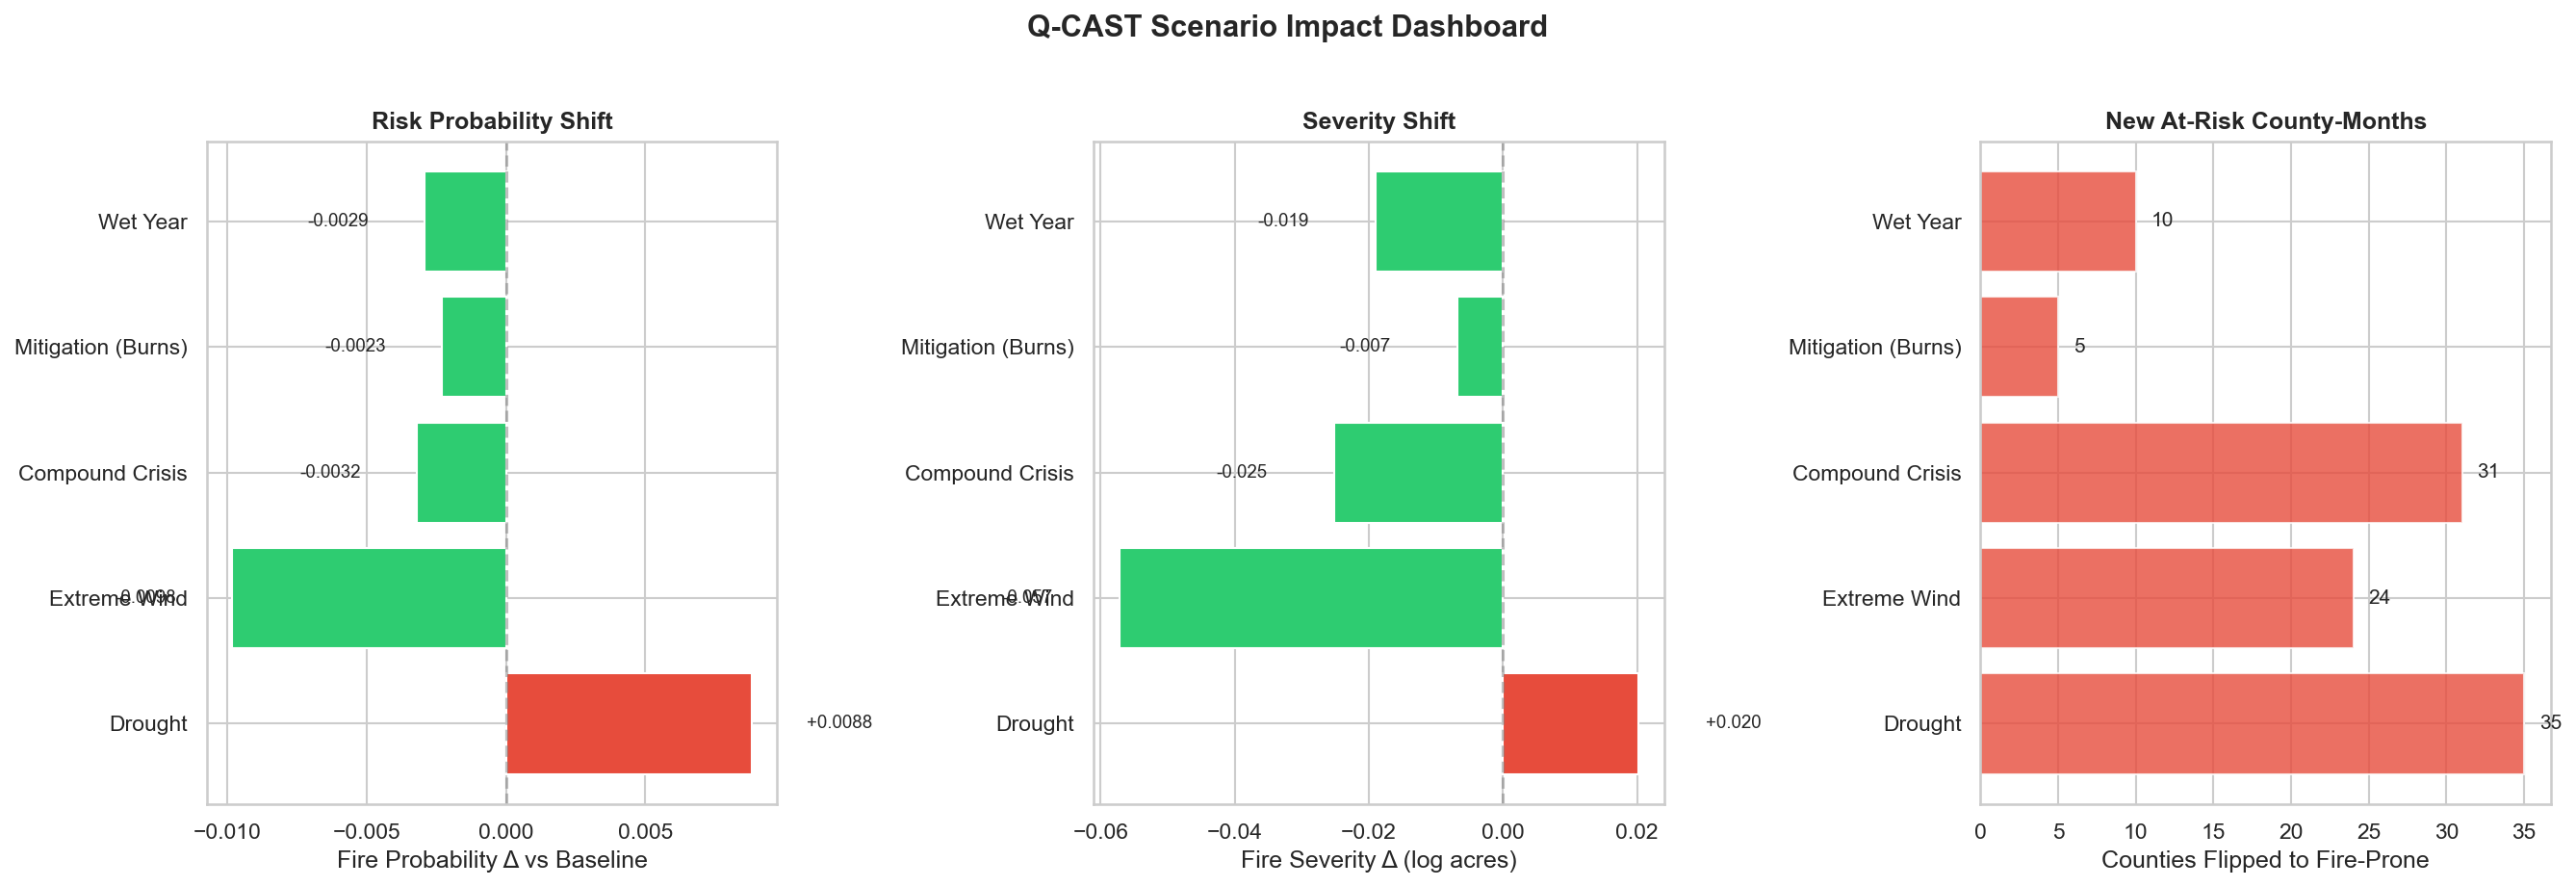

Saved: results/qcast_dashboard.png


In [19]:
# ── Visualization 1: Scenario comparison dashboard ───────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

sc_names = [n for n in SCENARIOS.keys() if n != "Baseline"]
prob_deltas = [scenario_results[n]["prob_delta"] for n in sc_names]
sev_deltas = [scenario_results[n]["severity_delta"] for n in sc_names]
flip_counts = [scenario_results[n]["flipped_to_fire"] for n in sc_names]

colors_sc = ["#e74c3c" if d > 0 else "#2ecc71" for d in prob_deltas]

# Panel 1: Probability shift
ax = axes[0]
bars = ax.barh(sc_names, prob_deltas, color=colors_sc)
ax.axvline(x=0, color="grey", linestyle="--", alpha=0.5)
ax.set_xlabel("Fire Probability Δ vs Baseline")
ax.set_title("Risk Probability Shift", fontsize=12, fontweight="bold")
for bar, val in zip(bars, prob_deltas):
    x_pos = bar.get_width() + 0.002 if val >= 0 else bar.get_width() - 0.002
    ax.text(x_pos, bar.get_y() + bar.get_height()/2,
            f"{val:+.4f}", va="center", ha="left" if val >= 0 else "right", fontsize=9)

# Panel 2: Severity shift
ax = axes[1]
colors_sev = ["#e74c3c" if d > 0 else "#2ecc71" for d in sev_deltas]
bars = ax.barh(sc_names, sev_deltas, color=colors_sev)
ax.axvline(x=0, color="grey", linestyle="--", alpha=0.5)
ax.set_xlabel("Fire Severity Δ (log acres)")
ax.set_title("Severity Shift", fontsize=12, fontweight="bold")
for bar, val in zip(bars, sev_deltas):
    x_pos = bar.get_width() + 0.01 if val >= 0 else bar.get_width() - 0.01
    ax.text(x_pos, bar.get_y() + bar.get_height()/2,
            f"{val:+.3f}", va="center", ha="left" if val >= 0 else "right", fontsize=9)

# Panel 3: County flips
ax = axes[2]
ax.barh(sc_names, flip_counts, color="#e74c3c", alpha=0.8)
ax.set_xlabel("Counties Flipped to Fire-Prone")
ax.set_title("New At-Risk County-Months", fontsize=12, fontweight="bold")
for i, val in enumerate(flip_counts):
    ax.text(val + 1, i, str(val), va="center", fontsize=10)

plt.suptitle("Q-CAST Scenario Impact Dashboard", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("../../results/qcast_dashboard.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: results/qcast_dashboard.png")

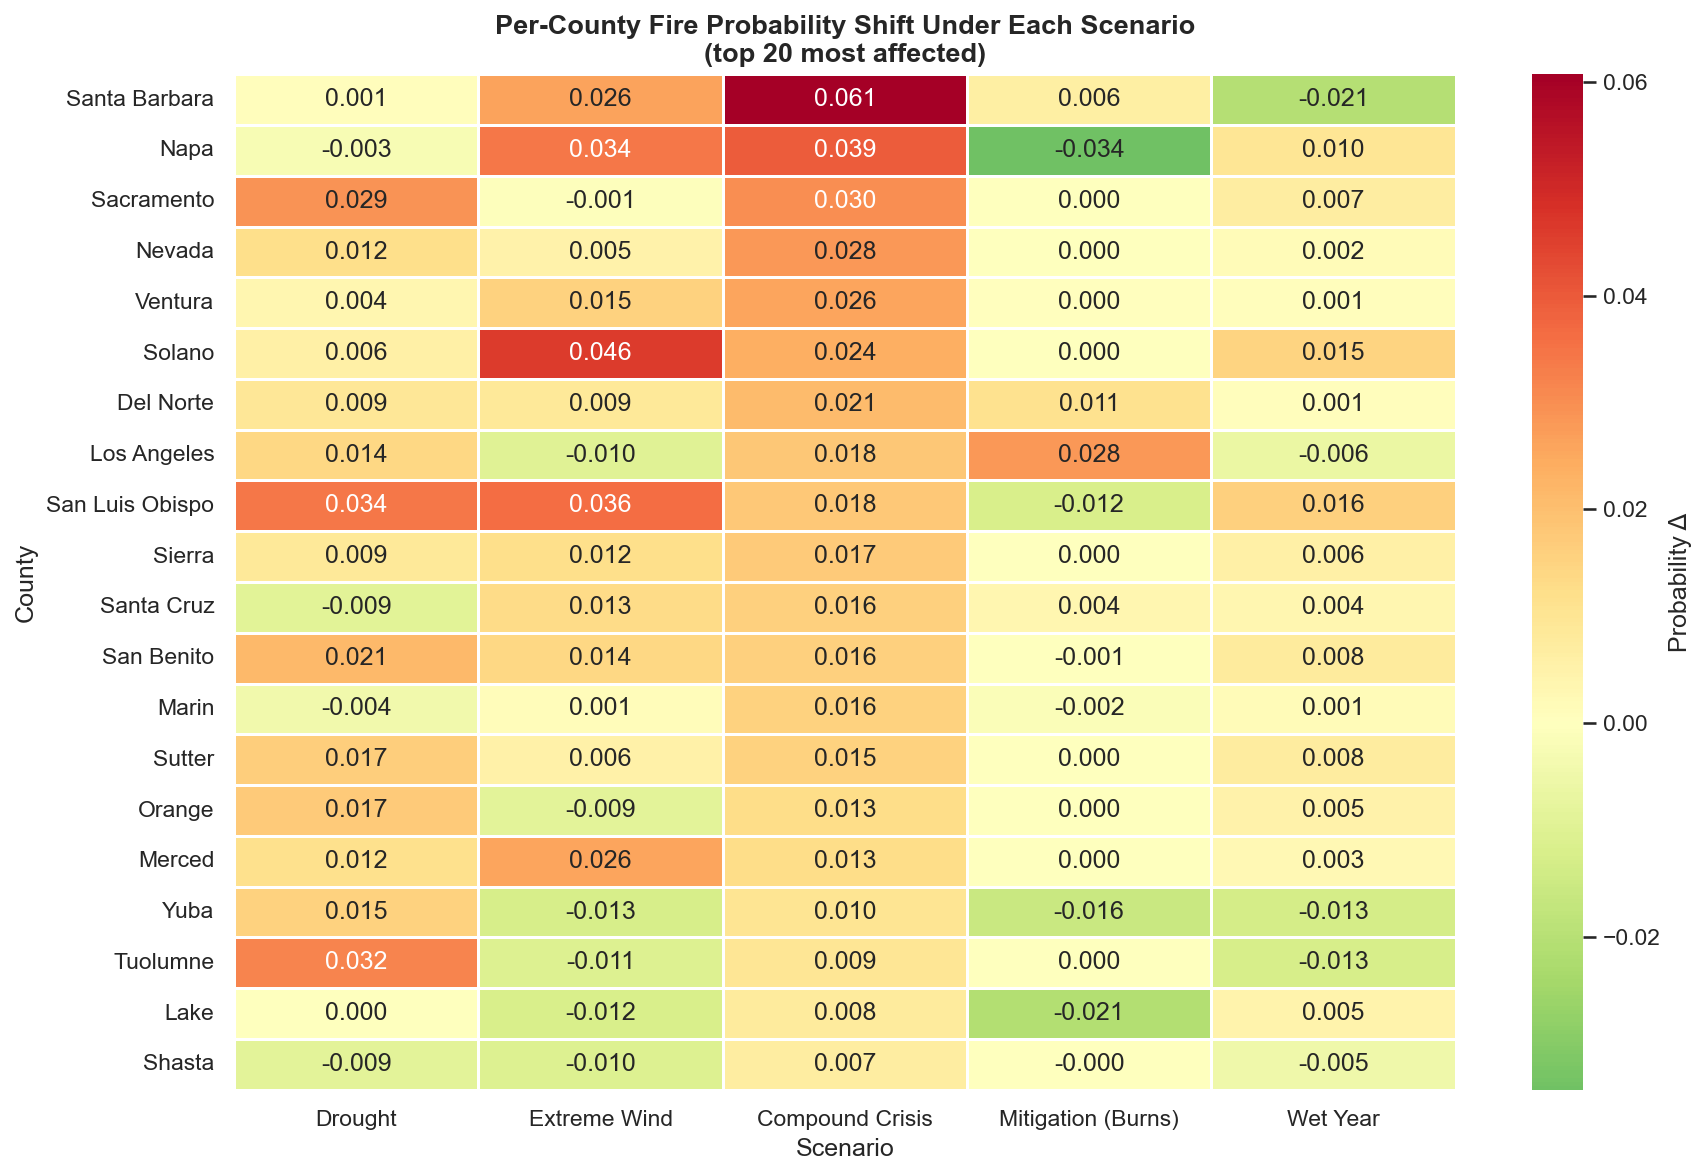

Saved: results/qcast_heatmap.png


In [20]:
# ── Visualization 2: County-level heatmap ────────────────────────────────────
# Build heatmap: counties x scenarios showing probability delta
heatmap_data = []
top_counties = impact_df.head(20)["County"].tolist()

for c_short in top_counties:
    row = {"County": c_short}
    c_full = c_short + " County"
    c_mask_test = test_counties == c_full

    for sc_name in sc_names:
        if c_mask_test.sum() > 0:
            sc_prob = scenario_results[sc_name]["probs"][c_mask_test].mean()
            base_prob = baseline_probs[c_mask_test].mean()
            row[sc_name] = round(sc_prob - base_prob, 4)
        else:
            row[sc_name] = 0
    heatmap_data.append(row)

hm_df = pd.DataFrame(heatmap_data).set_index("County")

fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(hm_df, annot=True, fmt=".3f", cmap="RdYlGn_r", center=0,
            linewidths=0.5, ax=ax, cbar_kws={"label": "Probability Δ"})
ax.set_title("Per-County Fire Probability Shift Under Each Scenario\n(top 20 most affected)",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Scenario")
plt.tight_layout()
plt.savefig("../../results/qcast_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: results/qcast_heatmap.png")

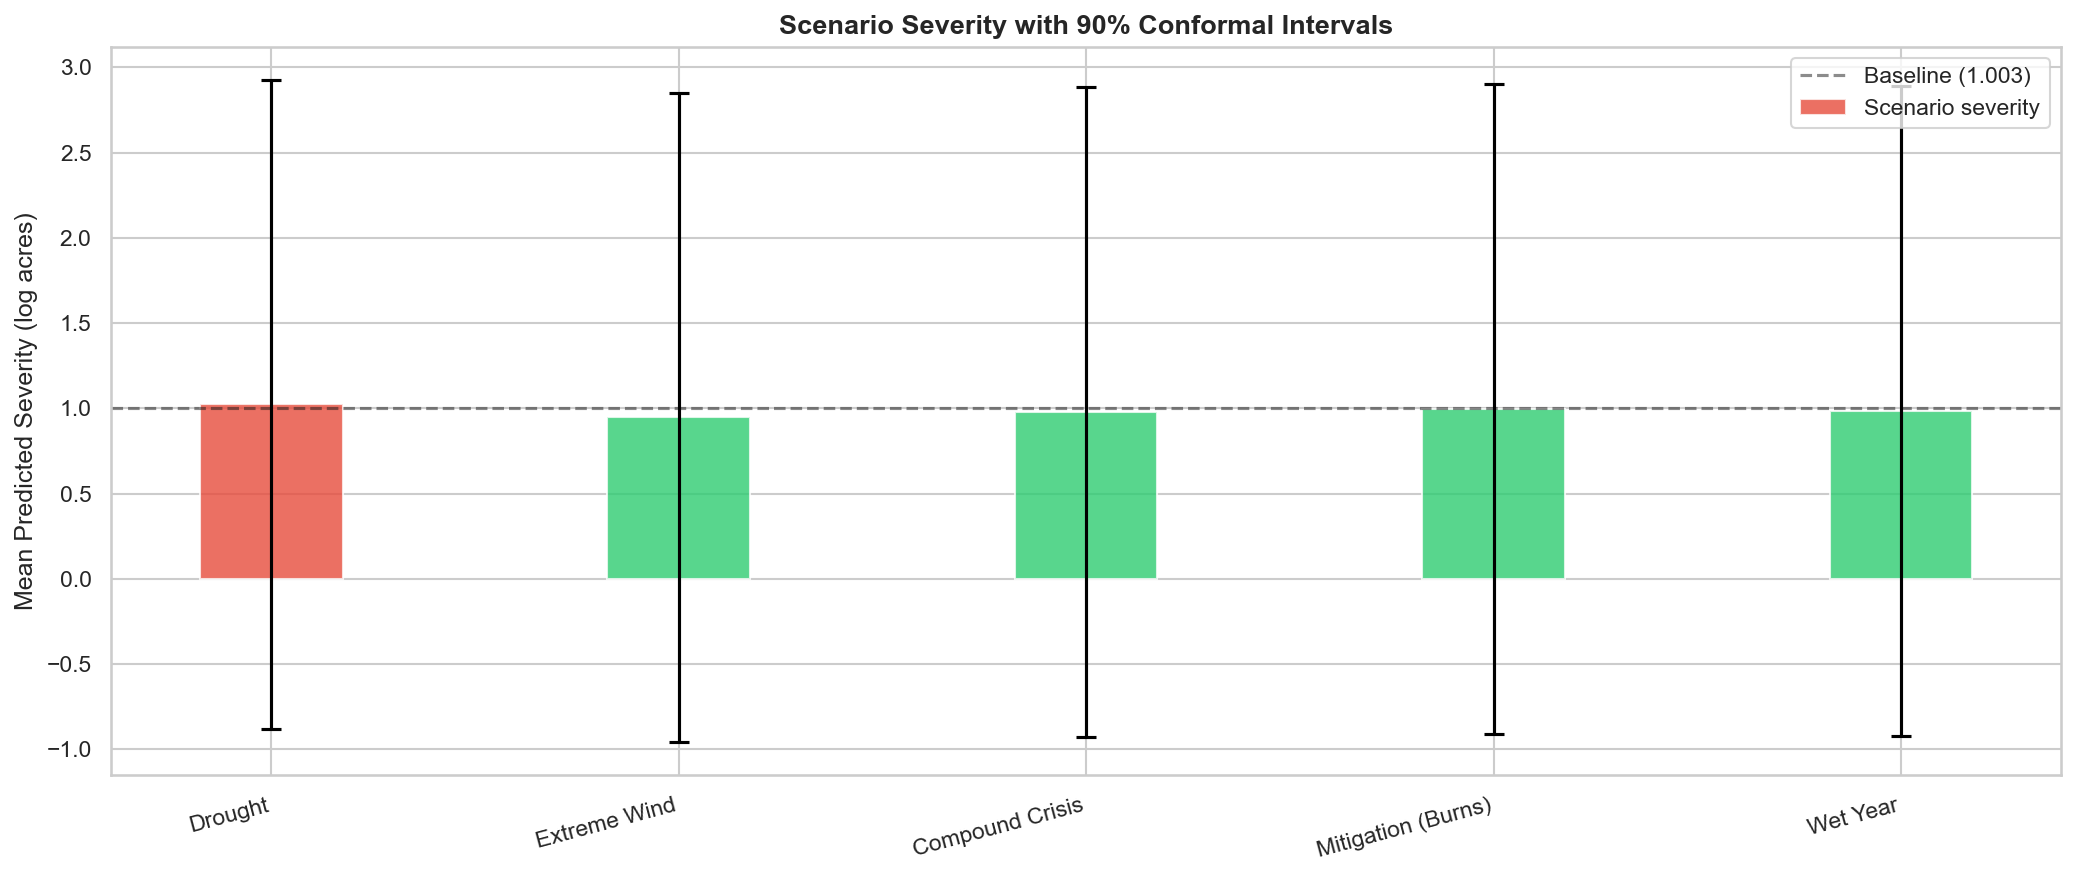

Saved: results/qcast_conformal_scenarios.png


In [21]:
# ── Visualization 3: Conformal scenario intervals ────────────────────────────
fig, ax = plt.subplots(figsize=(14, 6))

x_pos = np.arange(len(sc_names))
width = 0.35

mean_sevs = [scenario_results[n]["mean_severity"] for n in sc_names]
baseline_mean = scenario_results["Baseline"]["mean_severity"]

ax.bar(x_pos, mean_sevs, width, color=colors_sc, alpha=0.8, label="Scenario severity")
ax.axhline(y=baseline_mean, color="k", linestyle="--", alpha=0.5, label=f"Baseline ({baseline_mean:.3f})")

# Conformal bands
for i, sc in enumerate(sc_names):
    lo = scenario_results[sc]["mean_severity"] - q90
    hi = scenario_results[sc]["mean_severity"] + q90
    ax.errorbar(i, mean_sevs[i], yerr=q90, color="black", capsize=5, capthick=1.5, linewidth=1.5)

ax.set_xticks(x_pos)
ax.set_xticklabels(sc_names, rotation=15, ha="right")
ax.set_ylabel("Mean Predicted Severity (log acres)")
ax.set_title("Scenario Severity with 90% Conformal Intervals", fontsize=13, fontweight="bold")
ax.legend()

plt.tight_layout()
plt.savefig("../../results/qcast_conformal_scenarios.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: results/qcast_conformal_scenarios.png")

---
## 8 - Save Results

In [22]:
# ── Save results ─────────────────────────────────────────────────────────────
total_time = sum(timings.values())
print(f"=== RESOURCES ===")
print(f"  Qubits: {N_QUBITS}, Reservoir layers: {N_RESERVOIR_LAYERS}")
print(f"  Baseline encoding: {timings.get('baseline_encoding', 0):.1f}s")
print(f"  Scenarios encoded: {len(SCENARIOS) - 1} (baseline reused)")
print(f"  Total time: {total_time:.1f}s")

# Remove non-serializable arrays from results before saving
save_results = {}
for sc_name, res in scenario_results.items():
    save_results[sc_name] = {k: v for k, v in res.items()
                              if k not in ("probs", "severity")}

qcast_output = {
    "algorithm": "Q-CAST (Quantum Causal Scenario Transformer)",
    "notebook": "15_QCAST_Scenario_Transformer.ipynb",
    "quantum": {"qubits": N_QUBITS, "reservoir_layers": N_RESERVOIR_LAYERS},
    "baseline": {
        "f1": round(baseline_f1, 4),
        "auc": round(baseline_auc, 4),
        "r2": round(baseline_r2, 4),
    },
    "scenarios": save_results,
    "conformal_q90": round(q90, 4),
    "county_impact_worst_case": {
        "scenario": worst_scenario,
        "n_worsened": int(n_worsened),
        "n_stable": int(n_stable),
        "n_improved": int(n_improved),
    },
    "timings": {k: round(v, 2) for k, v in timings.items()},
}

with open("../../results/qcast_results.json", "w") as f:
    json.dump(qcast_output, f, indent=2)
print("\nSaved: results/qcast_results.json")

=== RESOURCES ===
  Qubits: 4, Reservoir layers: 10
  Baseline encoding: 94.6s
  Scenarios encoded: 5 (baseline reused)
  Total time: 573.8s

Saved: results/qcast_results.json


---
## Final Summary

**Q-CAST** turns our quantum model from a retrospective predictor into a forward-looking
decision-support engine. Instead of asking "what happened?" it asks **"what would happen if...?"**

**Key capabilities**:
- Simulates 6 plausible climate/mitigation scenarios through the full quantum pipeline
- Quantifies per-county risk shifts - which counties become more dangerous?
- Provides uncertainty-bounded predictions via conformal intervals
- Ranks scenarios by danger level: which climate futures are most catastrophic?

**Decision-support outputs**:
- *"If drought worsens by 30%, X counties flip from safe to fire-prone"*
- *"Controlled burns would reduce fire probability by Y across these counties"*
- *"The compound crisis scenario (drought + wind) is the worst case - Z counties at risk"*

**Relevance to insurance and policy**: California's regulatory framework increasingly
requires forward-looking catastrophe models. Q-CAST directly addresses this by providing
scenario-conditioned risk estimates that translate into actionable premium adjustments
and resource allocation decisions.
